# Parte 2: Red de Pases en Fútbol con Algoritmos de Búsqueda
**Tema:** IA aplicada al Rendimiento Deportivo

Modelamos una jugada de construcción ofensiva desde la defensa (DF) hasta el delantero (DL),
donde el peso de cada arista representa el riesgo de intercepción del pase (escala 1-10).

## Modelado del grafo

### Nodos (jugadores)
| Código | Jugador | Zona del campo |
|--------|---------|----------------|
| DF  | Defensa central | Zona defensiva |
| LT  | Lateral | Banda izquierda |
| MCD | Mediocampista defensivo | Pivote |
| MC1 | Mediocampista interior | Zona central |
| MC2 | Mediocampista ofensivo | Entre líneas |
| EX  | Extremo | Banda derecha |
| DL  | Delantero | Zona de finalización |


**Nota:** los resultados son dinámicos. Si modificas los pesos de las aristas en la celda del grafo (por ejemplo, cambiar `('LT', 2)` por `('LT', 9)` para simular un pase más presionado), vuelve a ejecutar las celdas siguientes en orden para que los algoritmos recalculen automáticamente las rutas y observes cómo cada uno reacciona ante distintos escenarios tácticos.


In [16]:
import networkx as nx
import matplotlib.pyplot as plt

In [17]:
G = nx.DiGraph()
for origen, destinos in grafo.items():
    for destino, peso in destinos:
        G.add_edge(origen, destino, weight=peso)

posiciones = {
    'DF':  (0, 1),
    'LT':  (1, 4),
    'MCD': (1, 2),
    'MC1': (2, 1),
    'MC2': (3, 2),
    'EX':  (3, 0),
    'DL':  (4, 1)
}

In [18]:
rutas = {
    'BFS': (bfs(grafo, INICIO, OBJETIVO)[0], 'blue'),
    'DFS': (dfs(grafo, INICIO, OBJETIVO)[0], 'orange'),
    'UCS': (ucs(grafo, INICIO, OBJETIVO)[0], 'green')
}

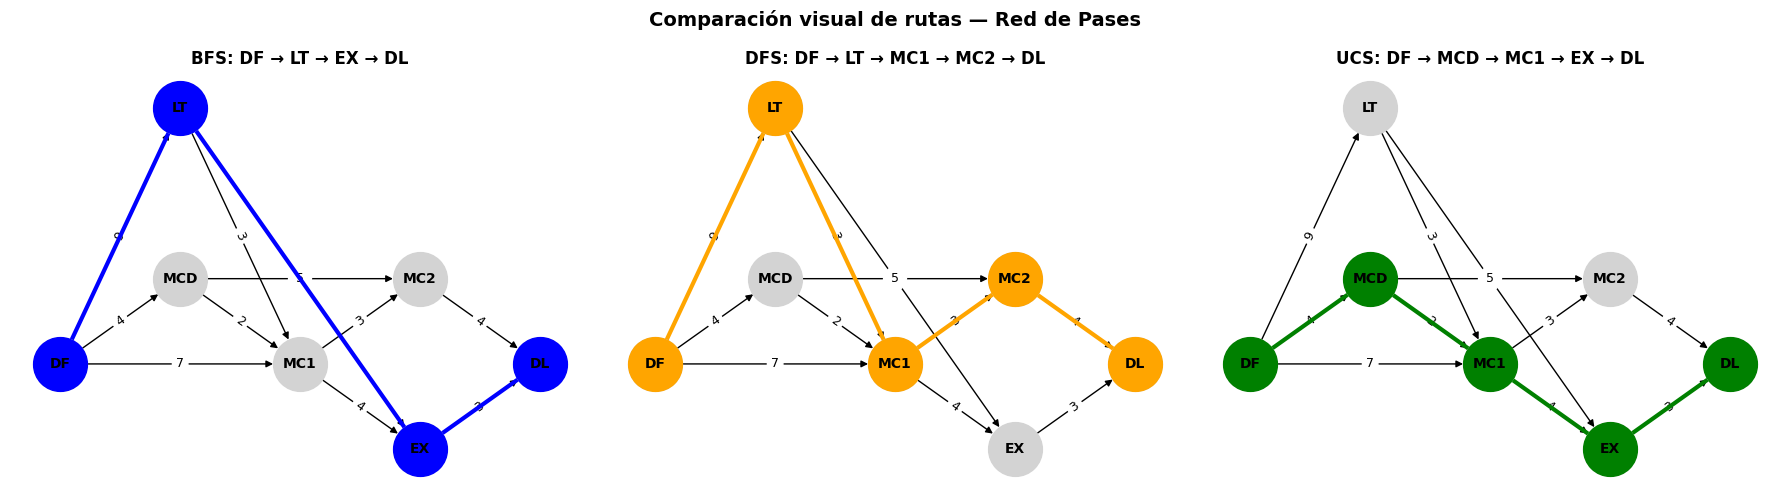

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nombre, (ruta, color)) in zip(axes, rutas.items()):
    nx.draw(G, posiciones, ax=ax, with_labels=True,
            node_color='lightgray', node_size=1500,
            font_size=10, font_weight='bold', arrows=True)

    etiquetas = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, posiciones, edge_labels=etiquetas,
                                  ax=ax, font_size=9)

    aristas_ruta = list(zip(ruta, ruta[1:]))
    nx.draw_networkx_edges(G, posiciones, edgelist=aristas_ruta,
                            ax=ax, edge_color=color, width=3, arrows=True)
    nx.draw_networkx_nodes(G, posiciones, nodelist=ruta,
                            ax=ax, node_color=color, node_size=1500)

    ax.set_title(f"{nombre}: {' → '.join(ruta)}", fontsize=12, fontweight='bold')

plt.suptitle("Comparación visual de rutas — Red de Pases",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()